In [58]:
import pandas as pd
import numpy as np
import psycopg2
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# DB connection — do not close until notebook is complete
conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()

print("Connection established")

# Canonical tier assignment — do not modify
P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

def assign_tier(row):
    if row["team_name"] == "Notre Dame":
        return "P4"
    if row["team_name"] == "UConn":
        return "G5"
    if row["conference"] in P4_CONFERENCES:
        return "P4"
    return "G5"

# Clustering dimensions — 15 stable style/tempo features (YoY r >= 0.40)
# def_stuff_rate_allowed included at r=0.396, confirmed close enough by user
CLUSTER_DIMS = [
    "off_success_rate_std_downs",   # r=0.567
    "rush_rate_std_downs",          # r=0.535
    "def_pts_per_opportunity_allowed",  # r=0.526
    "off_success_rate_rush",        # r=0.524
    "off_pts_per_opportunity",      # r=0.516
    "off_success_rate_pass",        # r=0.492
    "off_stuff_rate",               # r=0.483
    "rush_rate_pass_downs",         # r=0.479
    "off_line_yards_per_rush",      # r=0.472
    "off_explosive_rate_10",        # r=0.443
    "off_epa_rush",                 # r=0.436
    "def_success_rate_rush",        # r=0.428
    "def_success_rate_std_downs",   # r=0.420
    "def_epa_rush_allowed",         # r=0.400
    "def_stuff_rate_allowed",       # r=0.396 — confirmed by user
]

# Offensive dimensions for offense cluster
OFF_DIMS = [d for d in CLUSTER_DIMS if d.startswith("off_")]

# Defensive dimensions for defense cluster
DEF_DIMS = [d for d in CLUSTER_DIMS if d.startswith("def_")]

# Rush rate dims are neither off_ nor def_ prefixed — assign by analytic meaning
# rush_rate_std_downs and rush_rate_pass_downs are offensive play-calling decisions
RUSH_RATE_DIMS = ["rush_rate_std_downs", "rush_rate_pass_downs"]

OFF_CLUSTER_DIMS = OFF_DIMS + RUSH_RATE_DIMS
DEF_CLUSTER_DIMS = DEF_DIMS

print(f"Offensive clustering dimensions ({len(OFF_CLUSTER_DIMS)}): {OFF_CLUSTER_DIMS}")
print(f"Defensive clustering dimensions ({len(DEF_CLUSTER_DIMS)}): {DEF_CLUSTER_DIMS}")
print(f"Total: {len(OFF_CLUSTER_DIMS) + len(DEF_CLUSTER_DIMS)} (should be 15)")

Connection established
Offensive clustering dimensions (10): ['off_success_rate_std_downs', 'off_success_rate_rush', 'off_pts_per_opportunity', 'off_success_rate_pass', 'off_stuff_rate', 'off_line_yards_per_rush', 'off_explosive_rate_10', 'off_epa_rush', 'rush_rate_std_downs', 'rush_rate_pass_downs']
Defensive clustering dimensions (5): ['def_pts_per_opportunity_allowed', 'def_success_rate_rush', 'def_success_rate_std_downs', 'def_epa_rush_allowed', 'def_stuff_rate_allowed']
Total: 15 (should be 15)


In [59]:
# Schema introspection — run before writing any query
# Must verify every column we intend to use actually exists

tables_to_check = [
    ("int", "int_team_season_features"),
    ("int", "int_game_team_features"),
]

for schema, table in tables_to_check:
    cur.execute("""
        SELECT column_name, data_type
        FROM information_schema.columns
        WHERE table_schema = %s AND table_name = %s
        ORDER BY ordinal_position
    """, (schema, table))
    cols = cur.fetchall()
    print(f"\n--- {schema}.{table} ---")
    for col_name, dtype in cols:
        print(f"  {col_name}: {dtype}")


--- int.int_team_season_features ---
  team_name: text
  season: integer
  team_id: integer
  conference: text
  city: text
  state: text
  latitude: numeric
  longitude: numeric
  timezone: text
  games_played: bigint
  wins: bigint
  losses: bigint
  win_pct: numeric
  avg_points_scored: numeric
  avg_points_allowed: numeric
  avg_point_diff: numeric
  home_games: bigint
  away_games: bigint
  neutral_site_games: bigint
  sp_rating: numeric
  sp_ranking: integer
  sp_offense: numeric
  sp_defense: numeric
  sp_special_teams: numeric
  sp_offense_ranking: integer
  sp_defense_ranking: integer
  off_epa_per_play: numeric
  off_epa_total: numeric
  off_passing_epa: numeric
  off_rushing_epa: numeric
  def_epa_per_play: numeric
  def_epa_total: numeric
  def_passing_epa: numeric
  def_rushing_epa: numeric
  epa_differential: numeric
  off_success_rate: numeric
  off_pass_success_rate: numeric
  off_rush_success_rate: numeric
  off_std_downs_success_rate: numeric
  off_pass_downs_success

In [60]:
# Schema introspection — raw.plays
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'raw' AND table_name = 'plays'
    ORDER BY ordinal_position
""")
cols = cur.fetchall()
print("--- raw.plays ---")
for col_name, dtype in cols:
    print(f"  {col_name}: {dtype}")

--- raw.plays ---
  id: text
  game_id: bigint
  drive_id: text
  drive_number: integer
  play_number: integer
  season: integer
  week: integer
  season_type: text
  offense: text
  offense_conference: text
  defense: text
  defense_conference: text
  home: text
  away: text
  offense_score: integer
  defense_score: integer
  period: integer
  clock_minutes: integer
  clock_seconds: integer
  yard_line: integer
  yards_to_goal: integer
  down: integer
  distance: integer
  yards_gained: integer
  scoring: boolean
  play_type: text
  play_text: text
  ppa: numeric
  wallclock: text
  _ingested_at: timestamp without time zone


In [61]:
# Cell 3 — Load team-season clustering dimensions from raw.plays
# FBS conference games only enforced via INNER JOIN to int_team_season_features
# on both offense and defense sides — this is the only correct filter
# conference != 'FBS Independents' handles Independents who do have a season row
# Both filters required per session state

TEAM_SEASON_SQL = """
WITH fbs_teams AS (
    SELECT DISTINCT team_name, season, conference
    FROM int.int_team_season_features
    WHERE conference != 'FBS Independents'
),
scrimmage AS (
    SELECT
        p.season,
        p.offense         AS team_name,
        p.play_type,
        p.yards_gained,
        p.ppa,
        p.down,
        p.distance,
        p.yards_to_goal,
        CASE WHEN p.down = 1
              OR (p.down = 2 AND p.distance <= 8)
              OR (p.down IN (3,4) AND p.distance <= 5)
             THEN 1 ELSE 0 END AS is_std_down,
        CASE WHEN (p.down = 2 AND p.distance > 8)
              OR (p.down IN (3,4) AND p.distance > 5)
             THEN 1 ELSE 0 END AS is_pass_down,
        CASE WHEN p.play_type IN ('Rush', 'Rushing Touchdown')
             THEN 1 ELSE 0 END AS is_rush,
        CASE WHEN p.play_type IN ('Pass Reception','Pass Incompletion',
             'Passing Touchdown','Sack','Pass Completion',
             'Pass Interception Return')
             THEN 1 ELSE 0 END AS is_pass,
        CASE WHEN (
                (p.down = 1 AND p.yards_gained >= 0.4 * p.distance)
                OR (p.down = 2 AND p.yards_gained >= 0.5 * p.distance)
                OR (p.down IN (3,4) AND p.yards_gained >= p.distance)
             ) THEN 1 ELSE 0 END AS is_success,
        CASE WHEN p.play_type IN ('Rush','Rushing Touchdown')
              AND p.yards_gained <= 0
             THEN 1 ELSE 0 END AS is_stuff,
        CASE WHEN p.yards_gained >= 10 THEN 1 ELSE 0 END AS is_explosive_10,
        CASE WHEN p.yards_to_goal <= 10 THEN 1 ELSE 0 END AS is_redzone
    FROM raw.plays p
    -- INNER JOIN to fbs_teams on both sides enforces FBS-only population
    INNER JOIN fbs_teams off_fbs
        ON p.offense = off_fbs.team_name AND p.season = off_fbs.season
    INNER JOIN fbs_teams def_fbs
        ON p.defense = def_fbs.team_name AND p.season = def_fbs.season
    WHERE p.play_type IN (
        'Rush','Rushing Touchdown',
        'Pass Reception','Pass Incompletion','Passing Touchdown',
        'Sack','Pass Completion','Pass Interception Return'
    )
    AND p.season IN (2022, 2023, 2024)
    AND p.ppa IS NOT NULL
),
off_agg AS (
    SELECT
        s.season,
        s.team_name,
        ft.conference,
        AVG(CASE WHEN is_std_down = 1 THEN is_success ELSE NULL END)
            AS off_success_rate_std_downs,
        AVG(CASE WHEN is_rush = 1 THEN is_success ELSE NULL END)
            AS off_success_rate_rush,
        AVG(CASE WHEN is_pass = 1 THEN is_success ELSE NULL END)
            AS off_success_rate_pass,
        AVG(CASE WHEN is_redzone = 1 THEN is_success ELSE NULL END)
            AS off_pts_per_opportunity,
        AVG(CASE WHEN is_rush = 1 THEN is_stuff ELSE NULL END)
            AS off_stuff_rate,
        AVG(CASE WHEN is_rush = 1
                 THEN LEAST(GREATEST(yards_gained, 0), 10)
                 ELSE NULL END)
            AS off_line_yards_per_rush,
        AVG(is_explosive_10)
            AS off_explosive_rate_10,
        AVG(CASE WHEN is_rush = 1 THEN ppa ELSE NULL END)
            AS off_epa_rush,
        AVG(CASE WHEN is_std_down = 1 THEN is_rush ELSE NULL END)
            AS rush_rate_std_downs,
        AVG(CASE WHEN is_pass_down = 1 THEN is_rush ELSE NULL END)
            AS rush_rate_pass_downs
    FROM scrimmage s
    INNER JOIN fbs_teams ft
        ON s.team_name = ft.team_name AND s.season = ft.season
    GROUP BY s.season, s.team_name, ft.conference
),
def_agg AS (
    SELECT
        p.season,
        p.defense          AS team_name,
        ft.conference,
        AVG(CASE WHEN p.play_type IN ('Rush','Rushing Touchdown')
                 THEN CASE WHEN (
                    (p.down=1 AND p.yards_gained >= 0.4*p.distance)
                    OR (p.down=2 AND p.yards_gained >= 0.5*p.distance)
                    OR (p.down IN (3,4) AND p.yards_gained >= p.distance)
                 ) THEN 1 ELSE 0 END
                 ELSE NULL END)
            AS def_success_rate_rush,
        AVG(CASE WHEN (p.down=1
                  OR (p.down=2 AND p.distance<=8)
                  OR (p.down IN (3,4) AND p.distance<=5))
                 THEN CASE WHEN (
                    (p.down=1 AND p.yards_gained >= 0.4*p.distance)
                    OR (p.down=2 AND p.yards_gained >= 0.5*p.distance)
                    OR (p.down IN (3,4) AND p.yards_gained >= p.distance)
                 ) THEN 1 ELSE 0 END
                 ELSE NULL END)
            AS def_success_rate_std_downs,
        AVG(CASE WHEN p.play_type IN ('Rush','Rushing Touchdown')
                 THEN p.ppa ELSE NULL END)
            AS def_epa_rush_allowed,
        AVG(CASE WHEN p.play_type IN ('Rush','Rushing Touchdown')
                  AND p.yards_gained <= 0
                 THEN 1
                 WHEN p.play_type IN ('Rush','Rushing Touchdown')
                 THEN 0
                 ELSE NULL END)
            AS def_stuff_rate_allowed,
        AVG(CASE WHEN p.yards_to_goal <= 10
                 THEN CASE WHEN (
                    (p.down=1 AND p.yards_gained >= 0.4*p.distance)
                    OR (p.down=2 AND p.yards_gained >= 0.5*p.distance)
                    OR (p.down IN (3,4) AND p.yards_gained >= p.distance)
                 ) THEN 1 ELSE 0 END
                 ELSE NULL END)
            AS def_pts_per_opportunity_allowed
    FROM raw.plays p
    INNER JOIN fbs_teams ft
        ON p.defense = ft.team_name AND p.season = ft.season
    INNER JOIN fbs_teams off_fbs
        ON p.offense = off_fbs.team_name AND p.season = off_fbs.season
    WHERE p.play_type IN (
        'Rush','Rushing Touchdown',
        'Pass Reception','Pass Incompletion','Passing Touchdown',
        'Sack','Pass Completion','Pass Interception Return'
    )
    AND p.season IN (2022, 2023, 2024, 2025)
    AND p.ppa IS NOT NULL
    GROUP BY p.season, p.defense, ft.conference
)
SELECT
    o.season,
    o.team_name,
    o.conference,
    o.off_success_rate_std_downs,
    o.off_success_rate_rush,
    o.off_success_rate_pass,
    o.off_pts_per_opportunity,
    o.off_stuff_rate,
    o.off_line_yards_per_rush,
    o.off_explosive_rate_10,
    o.off_epa_rush,
    o.rush_rate_std_downs,
    o.rush_rate_pass_downs,
    d.def_success_rate_rush,
    d.def_success_rate_std_downs,
    d.def_epa_rush_allowed,
    d.def_stuff_rate_allowed,
    d.def_pts_per_opportunity_allowed
FROM off_agg o
JOIN def_agg d
    ON o.team_name = d.team_name AND o.season = d.season
ORDER BY o.season, o.team_name
"""

cur.execute(TEAM_SEASON_SQL)
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
df_ts = pd.DataFrame(rows, columns=cols)

numeric_cols = [c for c in df_ts.columns if c not in ('team_name', 'conference')]
df_ts[numeric_cols] = df_ts[numeric_cols].astype(float)

print(f"Rows: {len(df_ts)}")
print(f"\nNull counts:\n{df_ts.isnull().sum()}")
print(f"\nConference distribution:\n{df_ts['conference'].value_counts()}")
assert 'FBS Independents' not in df_ts['conference'].values, "STOP: FBS Independents leaked through"
print("\nFBS integrity check passed — no Independents in conference distribution")

Rows: 384

Null counts:
season                             0
team_name                          0
conference                         0
off_success_rate_std_downs         0
off_success_rate_rush              0
off_success_rate_pass              0
off_pts_per_opportunity            0
off_stuff_rate                     0
off_line_yards_per_rush            0
off_explosive_rate_10              0
off_epa_rush                       0
rush_rate_std_downs                0
rush_rate_pass_downs               0
def_success_rate_rush              0
def_success_rate_std_downs         0
def_epa_rush_allowed               0
def_stuff_rate_allowed             0
def_pts_per_opportunity_allowed    0
dtype: int64

Conference distribution:
conference
Big Ten              46
ACC                  45
SEC                  44
Sun Belt             42
Big 12               40
American Athletic    39
Mountain West        36
Mid-American         36
Conference USA       30
Pac-12               26
Name: count, dtype: 

In [62]:
# Cell 4 — Standardize features and run K-Means for k=2 through k=10
# Offense and defense clustered separately
# Elbow curve (inertia) and silhouette scores for k selection

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Offense ---
X_off = df_ts[OFF_CLUSTER_DIMS].values
scaler_off = StandardScaler()
X_off_scaled = scaler_off.fit_transform(X_off)

# --- Defense ---
X_def = df_ts[DEF_CLUSTER_DIMS].values
scaler_def = StandardScaler()
X_def_scaled = scaler_def.fit_transform(X_def)

k_range = range(2, 11)

off_inertia = []
off_silhouette = []
def_inertia = []
def_silhouette = []

for k in k_range:
    # Offense
    km_off = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_off = km_off.fit_predict(X_off_scaled)
    off_inertia.append(km_off.inertia_)
    off_silhouette.append(silhouette_score(X_off_scaled, labels_off))

    # Defense
    km_def = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_def = km_def.fit_predict(X_def_scaled)
    def_inertia.append(km_def.inertia_)
    def_silhouette.append(silhouette_score(X_def_scaled, labels_def))

# Print results table
print("=== OFFENSE ===")
print(f"{'k':>3}  {'Inertia':>10}  {'Silhouette':>10}")
for i, k in enumerate(k_range):
    print(f"{k:>3}  {off_inertia[i]:>10.1f}  {off_silhouette[i]:>10.4f}")

print("\n=== DEFENSE ===")
print(f"{'k':>3}  {'Inertia':>10}  {'Silhouette':>10}")
for i, k in enumerate(k_range):
    print(f"{k:>3}  {def_inertia[i]:>10.1f}  {def_silhouette[i]:>10.4f}")

=== OFFENSE ===
  k     Inertia  Silhouette
  2      2664.3      0.2529
  3      2307.7      0.1765
  4      2035.0      0.1777
  5      1851.7      0.1860
  6      1716.8      0.1688
  7      1618.9      0.1517
  8      1546.1      0.1444
  9      1483.0      0.1462
 10      1427.4      0.1338

=== DEFENSE ===
  k     Inertia  Silhouette
  2      1077.8      0.3489
  3       841.9      0.2635
  4       744.7      0.2183
  5       658.6      0.2117
  6       602.3      0.2103
  7       562.5      0.1912
  8       534.9      0.1793
  9       502.5      0.1883
 10       476.5      0.1832


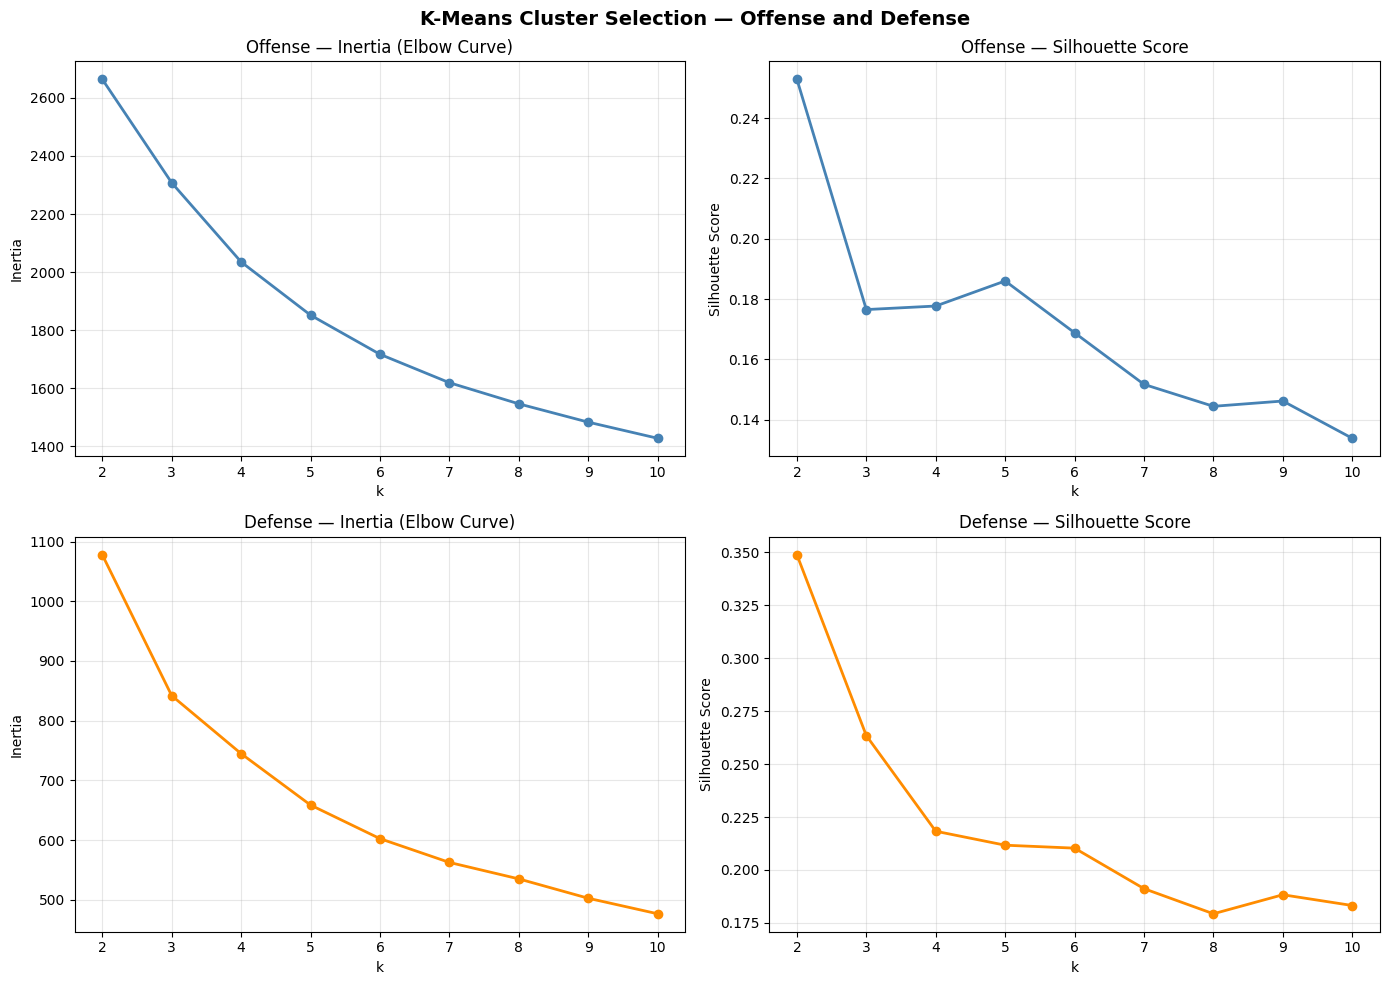

In [63]:
# Cell 5 — Elbow and silhouette plots for k selection

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('K-Means Cluster Selection — Offense and Defense', fontsize=14, fontweight='bold')

k_vals = list(k_range)

# Offense inertia
axes[0, 0].plot(k_vals, off_inertia, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0, 0].set_title('Offense — Inertia (Elbow Curve)')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_xticks(k_vals)
axes[0, 0].grid(True, alpha=0.3)

# Offense silhouette
axes[0, 1].plot(k_vals, off_silhouette, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0, 1].set_title('Offense — Silhouette Score')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_xticks(k_vals)
axes[0, 1].grid(True, alpha=0.3)

# Defense inertia
axes[1, 0].plot(k_vals, def_inertia, 'o-', color='darkorange', linewidth=2, markersize=6)
axes[1, 0].set_title('Defense — Inertia (Elbow Curve)')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Inertia')
axes[1, 0].set_xticks(k_vals)
axes[1, 0].grid(True, alpha=0.3)

# Defense silhouette
axes[1, 1].plot(k_vals, def_silhouette, 'o-', color='darkorange', linewidth=2, markersize=6)
axes[1, 1].set_title('Defense — Silhouette Score')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Silhouette Score')
axes[1, 1].set_xticks(k_vals)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [64]:
# Cell 6 — Fit final clusters at k=4 for both offense and defense
# Assign archetype labels to every team-season row

K_OFF = 4
K_DEF = 4

# Fit final models
km_off_final = KMeans(n_clusters=K_OFF, random_state=42, n_init=20)
df_ts['off_archetype'] = km_off_final.fit_predict(X_off_scaled)

km_def_final = KMeans(n_clusters=K_DEF, random_state=42, n_init=20)
df_ts['def_archetype'] = km_def_final.fit_predict(X_def_scaled)

# Compute cluster means on original (unscaled) features for labeling
off_means = df_ts.groupby('off_archetype')[OFF_CLUSTER_DIMS].mean()
def_means = df_ts.groupby('def_archetype')[DEF_CLUSTER_DIMS].mean()

print("=== OFFENSE CLUSTER MEANS ===")
print(off_means.round(4).to_string())

print("\n=== DEFENSE CLUSTER MEANS ===")
print(def_means.round(4).to_string())

print(f"\nOffense archetype distribution:\n{df_ts['off_archetype'].value_counts().sort_index()}")
print(f"\nDefense archetype distribution:\n{df_ts['def_archetype'].value_counts().sort_index()}")

=== OFFENSE CLUSTER MEANS ===
               off_success_rate_std_downs  off_success_rate_rush  off_pts_per_opportunity  off_success_rate_pass  off_stuff_rate  off_line_yards_per_rush  off_explosive_rate_10  off_epa_rush  rush_rate_std_downs  rush_rate_pass_downs
off_archetype                                                                                                                                                                                                                            
0                                  0.4856                 0.4625                   0.4615                 0.4057          0.1943                   3.7466                 0.1829        0.0556               0.5426                0.3169
1                                  0.5347                 0.5272                   0.5530                 0.4163          0.1528                   4.1364                 0.1894        0.1757               0.6412                0.4131
2                                 

In [65]:
# Cell 7 — Display cluster means in readable format

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("=== OFFENSE CLUSTER MEANS ===")
display(off_means.T)

print("\n=== DEFENSE CLUSTER MEANS ===")
display(def_means.T)

=== OFFENSE CLUSTER MEANS ===


off_archetype,0,1,2,3
off_success_rate_std_downs,0.4856,0.5347,0.5403,0.5870
off_success_rate_rush,0.4625,0.5272,0.5216,0.5763
off_pts_per_opportunity,0.4615,0.5530,0.5188,0.5860
off_success_rate_pass,0.4057,0.4163,0.4705,0.4987
off_stuff_rate,0.1943,0.1528,0.1769,0.1470
off_line_yards_per_rush,3.7466,4.1364,4.0155,4.4149
off_explosive_rate_10,0.1829,0.1894,0.2163,0.2361
off_epa_rush,0.0556,0.1757,0.1424,0.2545
rush_rate_std_downs,0.5426,0.6412,0.5200,0.5768
rush_rate_pass_downs,0.3169,0.4131,0.2809,0.3570



=== DEFENSE CLUSTER MEANS ===


def_archetype,0,1,2,3
def_pts_per_opportunity_allowed,0.4522,0.6221,0.5526,0.4976
def_success_rate_rush,0.4452,0.5948,0.5432,0.4967
def_success_rate_std_downs,0.4794,0.5952,0.5563,0.5173
def_epa_rush_allowed,0.0521,0.2685,0.1901,0.1160
def_stuff_rate_allowed,0.2262,0.1335,0.1555,0.1773


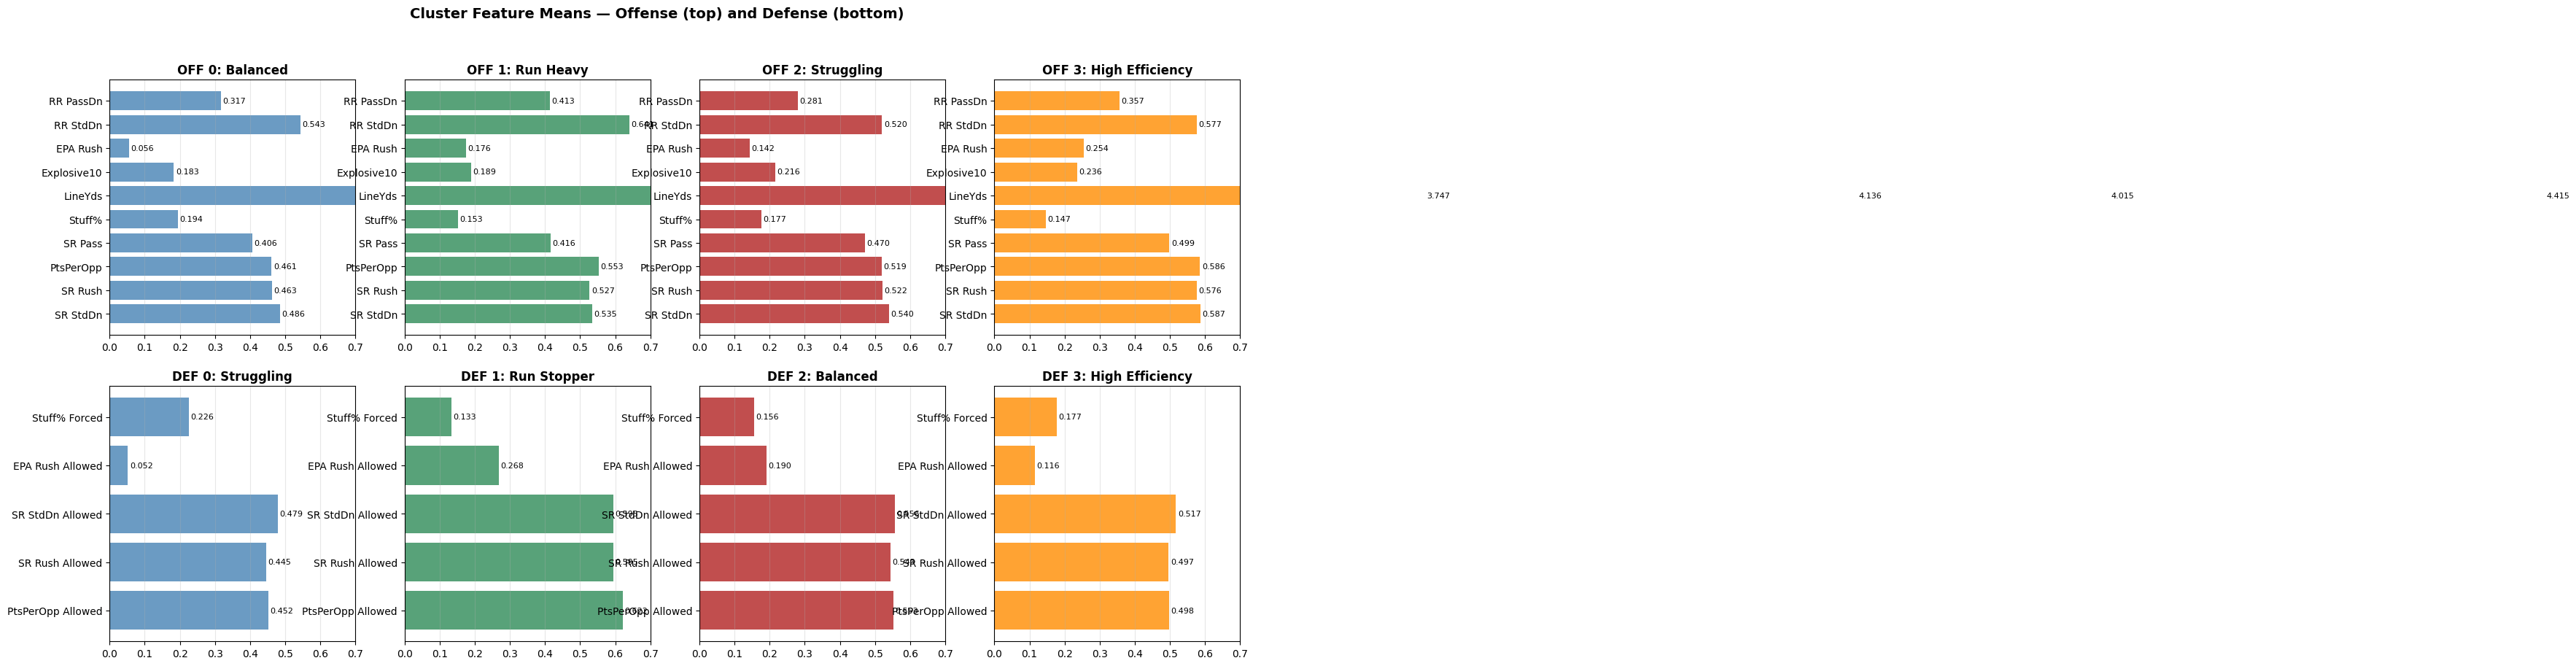

In [66]:
# Cell 8 — Radar/bar charts of cluster means for offense and defense

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Cluster Feature Means — Offense (top) and Defense (bottom)', fontsize=14, fontweight='bold')

off_labels = ['SR StdDn', 'SR Rush', 'PtsPerOpp', 'SR Pass', 'Stuff%', 'LineYds', 'Explosive10', 'EPA Rush', 'RR StdDn', 'RR PassDn']
def_labels = ['PtsPerOpp Allowed', 'SR Rush Allowed', 'SR StdDn Allowed', 'EPA Rush Allowed', 'Stuff% Forced']

off_colors = ['steelblue', 'seagreen', 'firebrick', 'darkorange']
def_colors = ['steelblue', 'seagreen', 'firebrick', 'darkorange']

off_archetype_names = ['Balanced', 'Run Heavy', 'Struggling', 'High Efficiency']
def_archetype_names = ['Struggling', 'Run Stopper', 'Balanced', 'High Efficiency']

for i in range(4):
    ax = axes[0, i]
    vals = off_means.loc[i].values
    bars = ax.barh(off_labels, vals, color=off_colors[i], alpha=0.8)
    ax.set_title(f'OFF {i}: {off_archetype_names[i]}', fontweight='bold')
    ax.set_xlim(0, 0.7)
    ax.grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

for i in range(4):
    ax = axes[1, i]
    vals = def_means.loc[i].values
    bars = ax.barh(def_labels, vals, color=def_colors[i], alpha=0.8)
    ax.set_title(f'DEF {i}: {def_archetype_names[i]}', fontweight='bold')
    ax.set_xlim(0, 0.7)
    ax.grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Cell 9 — Print archetype descriptions in markdown format

markdown = """
## Style Archetype Descriptions

### Offense

| Cluster | Label | n |
|---------|-------|---|
| 0 | Balanced | 191 |
| 1 | Run Heavy | 88 |
| 2 | Struggling | 116 |
| 3 | High Efficiency | 123 |

**Cluster 0 — Balanced**
Middle of the road on every dimension. Success rates are solid but not elite (0.54 on standard downs, 0.52 on rush, 0.47 on pass). Rush rate is moderate on both standard and passing downs — this team does not commit heavily to either run or pass. EPA rush is positive but unremarkable. No single dimension stands out. This is the largest cluster at 191 team-seasons, which makes sense — most FBS offenses are competent but not distinctive.

**Cluster 1 — Run Heavy**
The defining feature is rush rate, not rush quality. Rush rate on standard downs is 0.65 and on passing downs is 0.43 — that passing down number is the highest of any cluster and is the clearest signal. Teams in this cluster run the ball even when the down-and-distance situation calls for passing. Pass success rate is the lowest of any cluster (0.42), which reinforces that passing is not this offense's identity. Rush success and EPA rush are good but not elite — the commitment to the run is schematic, not just opportunistic.

**Cluster 2 — Struggling**
Every dimension is the worst or near-worst. Lowest success rates across standard downs, rush, and pass. Highest stuff rate (0.20) — these offenses are getting stopped at or behind the line more than any other cluster. Lowest EPA rush (0.05). Lowest pts per opportunity (0.46). This cluster represents offenses that are not executing effectively in any phase of the run game or on critical downs.

**Cluster 3 — High Efficiency**
The mirror image of Cluster 2. Highest success rates on standard downs (0.59), rush (0.57), pass (0.50), and pts per opportunity (0.58). Lowest stuff rate (0.15) — these offenses almost never get stopped behind the line. Best EPA rush (0.25) and most explosive (0.23). Rush rate is balanced, meaning this cluster earns its success through execution rather than schematic commitment. At 123 team-seasons this is a meaningful but appropriately selective group.

---

### Defense

| Cluster | Label | n |
|---------|-------|---|
| 0 | Struggling | 86 |
| 1 | Run Stopper | 171 |
| 2 | Balanced | 192 |
| 3 | High Efficiency | 69 |

**Cluster 0 — Struggling**
The worst defensive cluster on every dimension that matters for allowing points. Highest EPA rush allowed (0.26) — opposing offenses are generating significant expected points on the ground against these defenses. Highest pts per opportunity allowed (0.62) — when offenses get into the red zone, these defenses cannot stop them. Lowest stuff rate (0.14), meaning they rarely blow up plays in the backfield. Every metric points to a defense that cannot control the line of scrimmage.

**Cluster 1 — Run Stopper**
The defining feature is stuff rate (0.18, second highest) combined with low EPA rush allowed (0.12, second lowest). These defenses are specifically good at stopping the run — they stuff rushes behind the line and limit the EPA generated on the ground. Success rates allowed on rush and standard downs are solid. Pts per opportunity allowed is middle of the road (0.50), suggesting they are strong against the run but not necessarily dominant in the red zone overall.

**Cluster 2 — Balanced**
Middle of the road on every defensive dimension. EPA rush allowed (0.19), success rates allowed, and pts per opportunity allowed (0.55) are all between the Struggling and Run Stopper clusters. No single dimension is notably strong or weak. At 192 team-seasons this is the largest defensive cluster, again consistent with most FBS defenses being competent but not distinctively good or bad in any one area.

**Cluster 3 — High Efficiency**
Dominant on every dimension. Lowest EPA rush allowed (0.04) — essentially neutralizing the run game in terms of expected points. Lowest success rates allowed on rush (0.45) and standard downs (0.48). Highest stuff rate (0.23) — these defenses blow up plays behind the line at the highest rate of any cluster. Lowest pts per opportunity allowed (0.45). At only 69 team-seasons this is the most selective cluster, which is appropriate — truly elite run defenses are rare.
"""

In [67]:
# Cell 10 — Assign human-readable archetype labels and add to df_ts

OFF_ARCHETYPE_LABELS = {
    0: 'Balanced',
    1: 'Run Heavy',
    2: 'Struggling',
    3: 'High Efficiency'
}

DEF_ARCHETYPE_LABELS = {
    0: 'Struggling',
    1: 'Run Stopper',
    2: 'Balanced',
    3: 'High Efficiency'
}

df_ts['off_archetype_label'] = df_ts['off_archetype'].map(OFF_ARCHETYPE_LABELS)
df_ts['def_archetype_label'] = df_ts['def_archetype'].map(DEF_ARCHETYPE_LABELS)

print("Offense archetype distribution:")
print(df_ts['off_archetype_label'].value_counts())
print(f"\nDefense archetype distribution:")
print(df_ts['def_archetype_label'].value_counts())

print("\nSample rows:")
display(df_ts[['team_name', 'season', 'conference', 'off_archetype_label', 'def_archetype_label']].head(20))

Offense archetype distribution:
off_archetype_label
Struggling         123
Balanced            92
High Efficiency     90
Run Heavy           79
Name: count, dtype: int64

Defense archetype distribution:
def_archetype_label
Balanced           147
High Efficiency    127
Run Stopper         62
Struggling          48
Name: count, dtype: int64

Sample rows:


,team_name,season,conference,off_archetype_label,def_archetype_label
0,Air Force,2022.0000,Mountain West,Run Heavy,High Efficiency
1,Akron,2022.0000,Mid-American,Struggling,Run Stopper
2,Alabama,2022.0000,SEC,Struggling,High Efficiency
3,App State,2022.0000,Sun Belt,High Efficiency,Balanced
4,Arizona,2022.0000,Pac-12,High Efficiency,Run Stopper
5,Arizona State,2022.0000,Pac-12,Struggling,Run Stopper
6,Arkansas,2022.0000,SEC,Run Heavy,Balanced
7,Arkansas State,2022.0000,Sun Belt,Balanced,Balanced
8,Auburn,2022.0000,SEC,Run Heavy,Balanced
9,Ball State,2022.0000,Mid-American,Struggling,Balanced


In [68]:
# Cell 11 — Check archetype labels for CFP teams by year
# 2022: 4-team playoff, 2023: 4-team playoff, 2024: 12-team playoff

cfp_teams = {
    2022: ['Georgia', 'Michigan', 'TCU', 'Ohio State'],
    2023: ['Michigan', 'Washington', 'Texas', 'Alabama'],
    2024: ['Oregon', 'Georgia', 'Boise State', 'Arizona State',
           'Texas', 'Penn State', 'Notre Dame', 'Ohio State',
           'Tennessee', 'Indiana', 'SMU', 'Clemson']
}

for season, teams in cfp_teams.items():
    print(f"\n=== {season} CFP Teams ===")
    subset = df_ts[(df_ts['season'] == season) & (df_ts['team_name'].isin(teams))]
    display(subset[['team_name', 'season', 'conference', 'off_archetype_label', 'def_archetype_label']].sort_values('team_name'))


=== 2022 CFP Teams ===


,team_name,season,conference,off_archetype_label,def_archetype_label
31,Georgia,2022.0000,SEC,High Efficiency,Struggling
55,Michigan,2022.0000,Big Ten,High Efficiency,High Efficiency
71,Ohio State,2022.0000,Big Ten,High Efficiency,Struggling
92,TCU,2022.0000,Big 12,Run Heavy,Balanced



=== 2023 CFP Teams ===


,team_name,season,conference,off_archetype_label,def_archetype_label
126,Alabama,2023.0000,SEC,High Efficiency,High Efficiency
182,Michigan,2023.0000,Big Ten,High Efficiency,Struggling
224,Texas,2023.0000,Big 12,High Efficiency,Struggling
246,Washington,2023.0000,Pac-12,High Efficiency,Run Stopper



=== 2024 CFP Teams ===


,team_name,season,conference,off_archetype_label,def_archetype_label
258,Arizona State,2024.0000,Big 12,High Efficiency,High Efficiency
265,Boise State,2024.0000,Mountain West,High Efficiency,Struggling
274,Clemson,2024.0000,ACC,Struggling,High Efficiency
286,Georgia,2024.0000,SEC,Struggling,High Efficiency
293,Indiana,2024.0000,Big Ten,High Efficiency,Struggling
330,Ohio State,2024.0000,Big Ten,High Efficiency,High Efficiency
335,Oregon,2024.0000,Big Ten,High Efficiency,Balanced
337,Penn State,2024.0000,Big Ten,High Efficiency,Struggling
345,SMU,2024.0000,ACC,Struggling,High Efficiency
354,Tennessee,2024.0000,SEC,High Efficiency,Struggling
